In [3]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from xgboost import XGBClassifier
from pulseiq.ml_logic.registry import save_model, load_model
from pulseiq.ml_logic.train import train_model
from pulseiq.params import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
!wget 'https://data.mendeley.com/datasets/m8cgwxs9s6/2/files/4c109a9f-2462-4dce-b93c-5789168c5401'

--2026-08-27 15:57:16--  https://data.mendeley.com/datasets/m8cgwxs9s6/2/files/4c109a9f-2462-4dce-b93c-5789168c5401
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78277 (76K) [text/html]
Saving to: ‘4c109a9f-2462-4dce-b93c-5789168c5401.2’

4c109a9f-2462-4dce- 100%[===================>]  76.44K  --.-KB/s    in 0.07s   

2026-08-27 15:57:17 (1.04 MB/s) - ‘4c109a9f-2462-4dce-b93c-5789168c5401.2’ saved [78277/78277]



In [5]:
#!unzip raw_data/example.zip

In [6]:
path = "/home/davig/code/pulseIQ/raw_data/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh (1).csv"
df = pd.read_csv(path)
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [7]:
df1 = df.copy()

In [8]:
'''
Droping the ID columns
'''

df1 = df.drop(columns=['systolic_bp', 'diastolic_bp', 'family_diabetes', 'family_hypertension', 'glucose', 'stroke'])

In [9]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,Female,66,1.65,70.2,25.75,0,0,No
1,35,Female,60,1.47,42.5,19.58,0,0,No


In [10]:
'''
Binaryzing Diabetes to 0 = Normal and 1 = Diabetes
'''

map_diabetes = {
    'No': 0,
    'Yes': 1
}

df1['diabetic'] = df1['diabetic'].map(map_diabetes)

In [11]:
'''
Binaryzing Sex to 0 = Female and 1 = Male
'''

map_sex = {
    'Female': 0,
    'Male': 1
}

df1['gender'] = df1['gender'].map(map_sex)

In [12]:
df1.head(4)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0
2,62,0,57,1.52,47.0,20.24,0,0,0
3,73,1,55,1.63,57.4,21.72,0,0,0


In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   int64  
 2   pulse_rate              5288 non-null   int64  
 3   height                  5288 non-null   float64
 4   weight                  5288 non-null   float64
 5   bmi                     5288 non-null   float64
 6   hypertensive            5288 non-null   int64  
 7   cardiovascular_disease  5288 non-null   int64  
 8   diabetic                5288 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 371.9 KB


In [14]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0


In [15]:

'''
Scanling the dataset
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()




X_scaled = scaler.set_output(transform='pandas').fit_transform(df1[['age', 'pulse_rate', 'height', 'weight', 'bmi']])
y_diabetic = df1['diabetic']
y_hypertensive = df1['hypertensive']
y_cv = df1['cardiovascular_disease']


In [16]:
y_diabetic

0       0
1       0
2       0
3       0
4       0
       ..
5283    0
5284    1
5285    0
5286    0
5287    0
Name: diabetic, Length: 5288, dtype: int64

<Axes: >

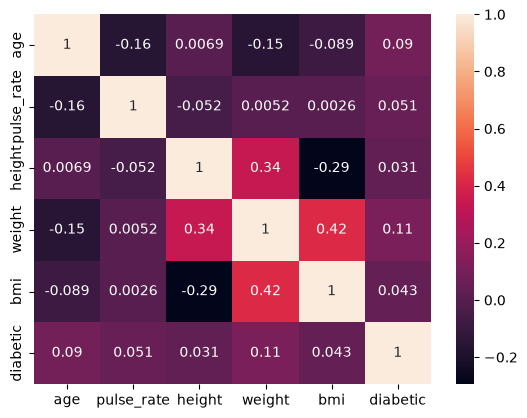

In [17]:
sns.heatmap(pd.concat([X_scaled, y_diabetic], axis=1).corr(), annot=True)

## Logistic Regression baseline

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier

model = LogisticRegression(random_state=42)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_scaled, y_diabetic, train_size=0.7, random_state=42, stratify=y_diabetic)

model.fit(X_train_d, y_train_d)

cv = cross_validate(model, X_train_d, y_train_d, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.683312668902541)

In [19]:
model = LogisticRegression(random_state=42)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_scaled, y_hypertensive, train_size=0.7, random_state=42, stratify=y_hypertensive)

model.fit(X_train_h, y_train_h)

cv = cross_validate(model, X_train_h, y_train_h, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7366587857844008)

In [20]:
model = LogisticRegression(random_state=42)

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_scaled, y_cv, train_size=0.7, random_state=42, stratify=y_cv)

model.fit(X_train_cv, y_train_cv)

cv = cross_validate(model, X_train_cv, y_train_cv, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7298592578472488)

In [21]:
from sklearn.metrics import roc_auc_score
def model_f(y):
    params={
        'n_estimators': 400,
        'max_depth': 6,
        'learning_rate': 0.9964688888846461,
        'min_child_weight': 1, 'subsample': 0.5004689439033313,
        'colsample_bytree': 0.7613304427154312,
        'gamma': 0.054181861010946, 'reg_alpha': 0.05914008164898518,
        'reg_lambda': 1.1933199710131277e-06
    }
    model_xgb = XGBClassifier(**params)

    model_xgb.fit(X_scaled, y)

    cv_xgb = cross_validate(model_xgb, X_scaled, y, cv=5, scoring=['roc_auc'])

    skf = StratifiedKFold(n_splits=5)
    skf.get_n_splits()

    scores = []

    for i, (train_index, test_index) in enumerate(skf.split(X_scaled, y)):
        X_train = X_scaled.iloc[train_index]
        y_train = y.iloc[train_index]
        X_test = X_scaled.iloc[test_index]
        y_test = y.iloc[test_index]

        model_xgb = XGBClassifier(eval_metric='logloss')

        model_xgb.fit(X_train, y_train)

        y_pred = model_xgb.predict_proba(X_test)[:, 1]


        scores.append(roc_auc_score(y_test, y_pred))
    return np.mean(scores)

In [22]:
scores_d = model_f(y_diabetic)
scores_h = model_f(y_hypertensive)
scores_cv = model_f(y_cv)

In [23]:
scores_d, scores_h, scores_cv

(np.float64(0.6603345635857357),
 np.float64(0.7026213661682676),
 np.float64(0.6345794032709098))

In [27]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X_scaled
y = y_diabetic

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X_scaled)
    y_arr = np.array(y_diabetic)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-27 15:59:14,297] A new study created in memory with name: no-name-e660204f-9d9d-48d4-8173-8e3105b3440a
[I 2026-08-27 15:59:18,763] Trial 0 finished with value: 0.6818532976121825 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.48215421894751337, 'min_child_weight': 8, 'subsample': 0.7305585516755807, 'colsample_bytree': 0.8828809977597516, 'gamma': 0.1378953095255674, 'reg_alpha': 6.252134138941906, 'reg_lambda': 0.8937249031492944}. Best is trial 0 with value: 0.6818532976121825.
[I 2026-08-27 15:59:23,842] Trial 1 finished with value: 0.6661117889541159 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.030894628552216766, 'min_child_weight': 1, 'subsample': 0.8339670422103482, 'colsample_bytree': 0.8539689068636704, 'gamma': 0.0017029996736989568, 'reg_alpha': 6.711819136056645e-08, 'reg_lambda': 3.6729960954813675e-05}. Best is trial 0 with value: 0.6818532976121

Mejor ROC_AUC: 0.722303156938209
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.04729776286828781, 'min_child_weight': 1, 'subsample': 0.9102094433321489, 'colsample_bytree': 0.8173178398675369, 'gamma': 2.902936126038991e-07, 'reg_alpha': 7.116614725318443, 'reg_lambda': 7.680562339078535e-07}


In [31]:
params = {
    "n_estimators": 100,
    "max_depth": 3,
    "learning_rate": 0.06978508228546695,
    "min_child_weight": 1,
    "subsample": 0.8321276547435521,
    "colsample_bytree": 0.7953657295471905,
    "gamma": 1.2924138770056416e-07,
    "reg_alpha": 0.35555313508365,
    "reg_lambda": 3.189114424075836e-07,
}

# 1. Unpack both variables (model and predictions)
model_t, y_pred = train_model(XGBClassifier, X_scaled, y_diabetic, params)

# 2. Pass only the model instance to save_model
save_model(model_t, "diabetic")


Fold 0: AUC = 0.6696
Fold 1: AUC = 0.7327
Fold 2: AUC = 0.7522
Fold 3: AUC = 0.7484
Fold 4: AUC = 0.7194
Mean AUC: 0.7245


In [32]:
model_d = load_model('diabetic')

prediction = model_d.predict(X_test_d)

prediction.mean()

np.float64(0.0)

## Hypertensive



In [33]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X_scaled
y = y_hypertensive

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X_scaled)
    y_arr = np.array(y_hypertensive)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20




               )

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-27 16:22:22,885] A new study created in memory with name: no-name-95345098-ed41-4a42-be83-c901bc87e920


[I 2026-08-27 16:22:51,137] Trial 0 finished with value: 0.7515627294052447 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 900, 'max_depth': 4, 'learning_rate': 0.0199772398723841, 'min_child_weight': 3, 'subsample': 0.9224161963785734, 'colsample_bytree': 0.5069520969010994, 'gamma': 1.4938308514395476e-06, 'reg_alpha': 1.8322602970943758, 'reg_lambda': 7.176844272177819}. Best is trial 0 with value: 0.7515627294052447.
[I 2026-08-27 16:23:06,524] Trial 1 finished with value: 0.6939737592835268 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.39713782947129367, 'min_child_weight': 5, 'subsample': 0.9844979160943503, 'colsample_bytree': 0.6372100692970848, 'gamma': 0.12466365655812484, 'reg_alpha': 1.4897165450362097e-06, 'reg_lambda': 6.694837245785018e-06}. Best is trial 0 with value: 0.7515627294052447.
[I 2026-08-27 16:23:17,179] Trial 2 finished with value: 0.7258023483052503 and parameters: {'classifier': 'XG

Mejor ROC_AUC: 0.7550984481012729
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.01633677972949858, 'min_child_weight': 4, 'subsample': 0.5013860735900012, 'colsample_bytree': 0.9695947543058647, 'gamma': 1.0692757820395279e-08, 'reg_alpha': 0.2720039623983692, 'reg_lambda': 4.689529077283384}


In [35]:
params = {
    'n_estimators': 600,
    'max_depth': 3,
    'learning_rate': 0.010100986524636394,
    'min_child_weight': 1,
    'subsample': 0.6988948174004668,
    'colsample_bytree': 0.7036209641032721,
    'gamma': 6.693716298679582e-07,
    'reg_alpha': 3.2877918020751725e-07,
    'reg_lambda': 5.290022255752686e-05,
}

# Unpack both variables
model_t, predict_t = train_model(
    XGBClassifier, X_scaled, y_hypertensive, params
)

# Pass the model to save_model
save_model(model_t, 'hypertensive')


Fold 0: AUC = 0.7217
Fold 1: AUC = 0.7713
Fold 2: AUC = 0.7344
Fold 3: AUC = 0.7767
Fold 4: AUC = 0.7729
Mean AUC: 0.7554


In [36]:
model_h = load_model('hypertensive')

prediction = model_h.predict(X_test_h)

prediction.mean()

np.float64(0.005671077504725898)

## Cardiovascular Disease

In [37]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X_scaled
y = y_cv

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }


    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X_scaled)
    y_arr = np.array(y_cv)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-27 16:28:25,883] A new study created in memory with name: no-name-6a7e43bc-530d-4146-ad38-a2066263376b


[I 2026-08-27 16:28:30,549] Trial 0 finished with value: 0.6642237535869919 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.038575575069202596, 'min_child_weight': 10, 'subsample': 0.8710724219647732, 'colsample_bytree': 0.6267192047019857, 'gamma': 1.6841179975969048e-06, 'reg_alpha': 0.002645824110774482, 'reg_lambda': 1.8280300844073427e-07}. Best is trial 0 with value: 0.6642237535869919.
[I 2026-08-27 16:28:39,015] Trial 1 finished with value: 0.6402845959850085 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05914734314082518, 'min_child_weight': 7, 'subsample': 0.6159031850931703, 'colsample_bytree': 0.5338571385972903, 'gamma': 2.4769320745716465e-06, 'reg_alpha': 1.4650255749891967e-08, 'reg_lambda': 0.11950802521758196}. Best is trial 0 with value: 0.6642237535869919.
[I 2026-08-27 16:28:46,596] Trial 2 finished with value: 0.6879546140686325 and parameters: {'class

Mejor ROC_AUC: 0.7024274367911784
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.20668680345661958, 'min_child_weight': 10, 'subsample': 0.5027860569180111, 'colsample_bytree': 0.7156464791272094, 'gamma': 1.462484853870368e-06, 'reg_alpha': 0.00010902123094586542, 'reg_lambda': 0.10046229762948441}


In [38]:
params = {
    'n_estimators': 100,
    'max_depth': 10,
    'learning_rate': 0.010030187483214029,
    'min_child_weight': 5,
    'subsample': 0.812765113697849,
    'colsample_bytree': 0.9417411410261993,
    'gamma': 0.0007193844317030003,
    'reg_alpha': 0.017635135956500642,
    'reg_lambda': 0.008032239868452896,
}

# Descompacta o modelo e as predições
model_t, predict_t = train_model(XGBClassifier, X_scaled, y_cv, params)

# Salva apenas o modelo
save_model(model_t, 'cv')


Fold 0: AUC = 0.5608
Fold 1: AUC = 0.8034
Fold 2: AUC = 0.7202
Fold 3: AUC = 0.7341
Fold 4: AUC = 0.5858
Mean AUC: 0.6809


In [39]:
model_cv = load_model('cv')

prediction = model_cv.predict(X_test_cv)

prediction.mean()

np.float64(0.0)